# Titled Tuesday — Exploratory Data Analysis

Dataset built by `build_dataset.py`: one row per game from the Feb 10 and Mar 10 2026 Titled Tuesday events. Target: `outcome` (win/draw/loss from White's perspective), strictly pre-game features only.

This notebook examines class balance, the rating→outcome relationship vs. the theoretical Elo curve, draw structure, in-tournament dynamics, and feature quality — each feeding directly into the modeling recommendations in `ANALYSIS.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_parquet("data/processed/games.parquet")
print(df.shape)
df.groupby("tournament")["outcome"].value_counts(normalize=True).unstack().round(3)

(4048, 86)


outcome,draw,loss,win
tournament,,,
titled-tuesday-blitz-february-10-2026-6221327,0.081,0.430,0.489
titled-tuesday-blitz-march-10-2026-6277141,0.074,0.452,0.474


## 1. Class balance and White's first-move advantage

Draws are rare (~8%) — titled blitz players play sharp, decisive chess. The class imbalance means accuracy is a weak metric (a win/loss-only classifier gets ~92% of the ceiling); we should evaluate with **log loss** and per-class recall. White scores ~52% of available points, consistent with the known first-move advantage.

In [2]:
print(df["outcome"].value_counts(normalize=True).round(4))
print(f"\nWhite mean score: {df['outcome_score'].mean():.4f}")
# White advantage conditioned on near-equal ratings (|diff| < 50)
equal = df[df["abs_diff_elo"] < 50]
print(f"White mean score when |Elo diff| < 50 (n={len(equal)}): {equal['outcome_score'].mean():.4f}")

outcome
win     0.4812
loss    0.4412
draw    0.0776
Name: proportion, dtype: float64

White mean score: 0.5200
White mean score when |Elo diff| < 50 (n=37): 0.5676


## 2. Rating difference vs. outcome — empirical curve vs. Elo logistic

The Elo model predicts an expected score $E = \sigma\big(\tfrac{\ln 10}{400} d\big) = \frac{1}{1+10^{-d/400}}$ where $d$ is the rating difference. If the empirical mean score tracks this curve, a single well-transformed feature already captures most signal — an argument for simple, calibrated models over capacity.

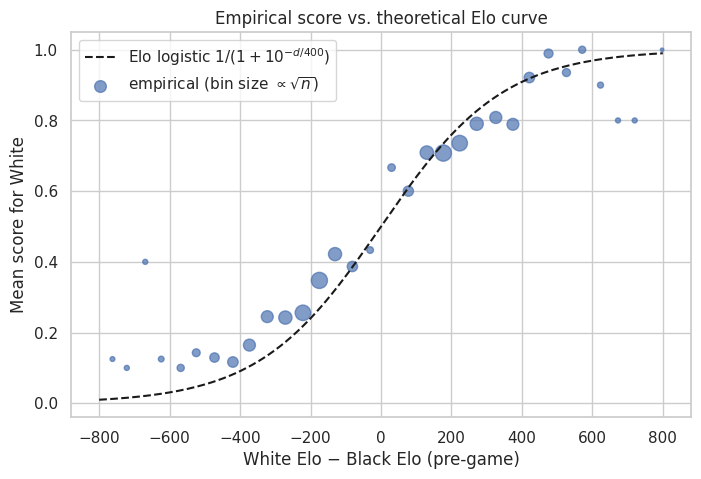

In [3]:
bins = np.arange(-800, 850, 50)
df["diff_bin"] = pd.cut(df["diff_elo"], bins)
emp = df.groupby("diff_bin", observed=True).agg(
    mean_score=("outcome_score", "mean"),
    n=("outcome_score", "size"),
    mid=("diff_elo", "mean"),
)
xs = np.linspace(-800, 800, 200)
elo_curve = 1 / (1 + 10 ** (-xs / 400))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, elo_curve, "k--", label="Elo logistic $1/(1+10^{-d/400})$")
ax.scatter(emp["mid"], emp["mean_score"], s=np.sqrt(emp["n"]) * 6, alpha=0.7, label="empirical (bin size $\\propto \\sqrt{n}$)")
ax.set_xlabel("White Elo − Black Elo (pre-game)")
ax.set_ylabel("Mean score for White")
ax.legend()
ax.set_title("Empirical score vs. theoretical Elo curve")
plt.show()

## 3. Draw structure

Draw probability is **not monotone in $d$** — it peaks at $d \approx 0$ and decays with $|d|$. A plain linear model on $d$ cannot represent this; we need either $|d|$ as a feature, an ordinal link (where the draw band sits between two thresholds on a latent scale), or a Davidson-style draw parameter. We also check whether stronger pairings draw more often (they do in classical; blitz attenuates this).

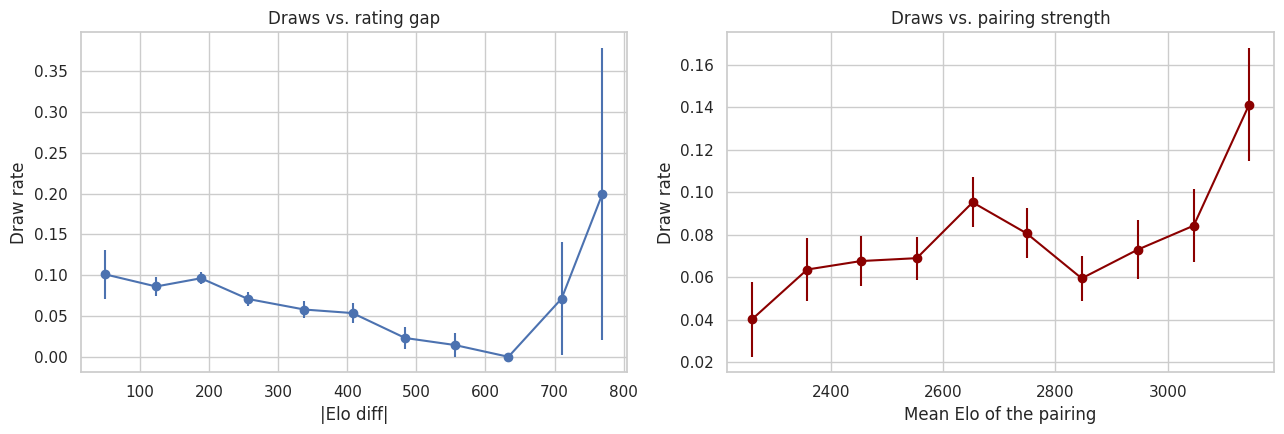

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["absdiff_bin"] = pd.cut(df["abs_diff_elo"], np.arange(0, 850, 75))
drw = df.groupby("absdiff_bin", observed=True).agg(
    draw_rate=("outcome", lambda s: (s == "draw").mean()), mid=("abs_diff_elo", "mean"), n=("outcome", "size"))
axes[0].errorbar(drw["mid"], drw["draw_rate"],
                 yerr=np.sqrt(drw["draw_rate"] * (1 - drw["draw_rate"]) / drw["n"]), fmt="o-")
axes[0].set_xlabel("|Elo diff|"); axes[0].set_ylabel("Draw rate"); axes[0].set_title("Draws vs. rating gap")

df["meanelo_bin"] = pd.cut(df["mean_elo"], np.arange(2200, 3300, 100))
drw2 = df.groupby("meanelo_bin", observed=True).agg(
    draw_rate=("outcome", lambda s: (s == "draw").mean()), mid=("mean_elo", "mean"), n=("outcome", "size"))
axes[1].errorbar(drw2["mid"], drw2["draw_rate"],
                 yerr=np.sqrt(drw2["draw_rate"] * (1 - drw2["draw_rate"]) / drw2["n"]), fmt="o-", color="darkred")
axes[1].set_xlabel("Mean Elo of the pairing"); axes[1].set_ylabel("Draw rate"); axes[1].set_title("Draws vs. pairing strength")
plt.tight_layout(); plt.show()

## 4. Swiss dynamics: rating gaps and outcomes by round

Swiss pairing matches similar scores, so round 1 (random-ish seeding by rating split) has enormous gaps that shrink as the field sorts itself. This induces **round-dependent difficulty**: predicting round 1 is easy, late rounds are harder. It also means rows are not i.i.d. — a reason to split by tournament rather than randomly.

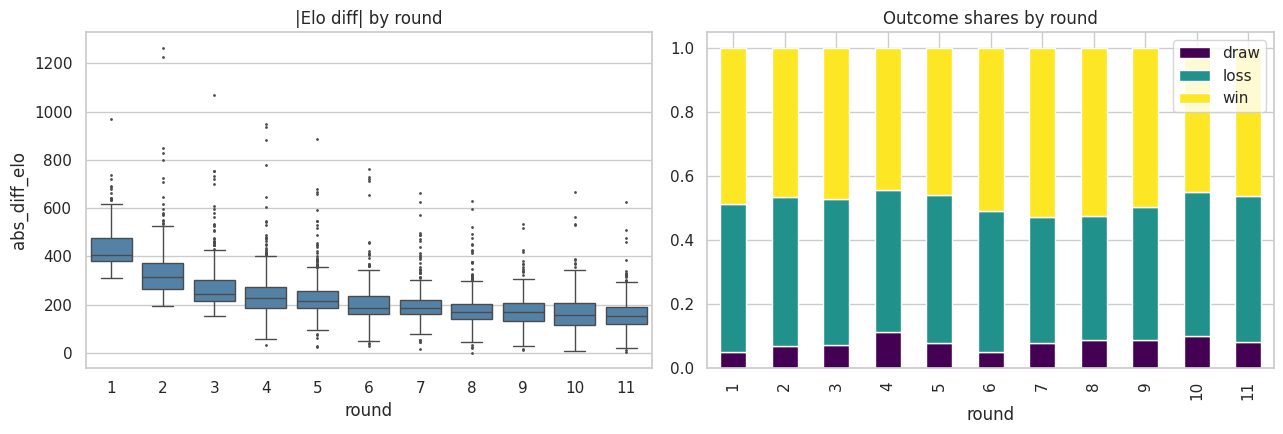

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="round", y="abs_diff_elo", ax=axes[0], color="steelblue", fliersize=1)
axes[0].set_title("|Elo diff| by round")
rate = df.groupby("round")["outcome"].value_counts(normalize=True).unstack()
rate.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Outcome shares by round"); axes[1].legend(title=None)
plt.tight_layout(); plt.show()

## 5. Do in-tournament form features add signal beyond Elo?

`perf_vs_expected` (points scored minus Elo-expected points in earlier rounds) is a residual-form indicator that is orthogonal to rating by construction. We check whether it correlates with outcome after controlling for `diff_elo` — a cheap proxy: correlation of outcome residuals (actual − Elo-expected score) with the form difference.

In [6]:
late = df[df["round"] >= 4].copy()  # need some history to be meaningful
late["residual"] = late["outcome_score"] - late["white_elo_expected"]
form_cols = ["diff_perf_vs_expected", "diff_score_rate", "diff_streak", "diff_points_so_far"]
print(late[["residual"] + form_cols].corr()["residual"].drop("residual").round(4))

diff_perf_vs_expected    0.0794
diff_score_rate          0.0051
diff_streak              0.0284
diff_points_so_far       0.0087
Name: residual, dtype: float64


## 6. Career / profile features: signal and missingness

Correlation of selected enrichment features with the numeric outcome, plus missingness. Caveat (documented in `ANALYSIS.md`): stats/profile endpoints are a **current snapshot**, not as-of-game-time, so slow-moving fields (account age, career volume, title) are safest.

In [7]:
feat = ["diff_elo", "white_elo_expected", "diff_title_ordinal", "diff_account_age_days",
        "diff_log_blitz_n_games", "diff_blitz_win_rate", "diff_blitz_rd", "diff_bullet_rating",
        "diff_rapid_rating", "diff_fide", "diff_puzzle_rush_best", "diff_perf_vs_expected"]
summary = pd.DataFrame({
    "corr_with_score": df[feat].corrwith(df["outcome_score"]).round(3),
    "missing_frac": df[feat].isna().mean().round(3),
})
summary.sort_values("corr_with_score", ascending=False)

,corr_with_score,missing_frac
white_elo_expected,0.523,0.000
diff_elo,0.516,0.000
diff_bullet_rating,0.407,0.115
diff_title_ordinal,0.342,0.000
diff_blitz_win_rate,0.299,0.001
diff_rapid_rating,0.271,0.223
diff_fide,0.250,0.510
diff_puzzle_rush_best,0.197,0.134
diff_log_blitz_n_games,0.173,0.001
diff_account_age_days,0.100,0.000


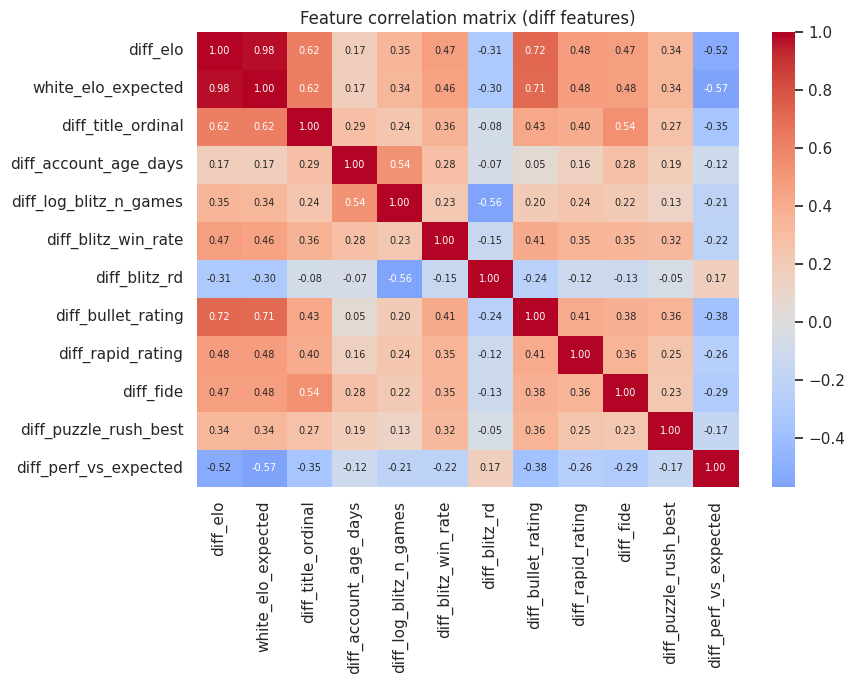

In [8]:
corr = df[feat].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Feature correlation matrix (diff features)")
plt.tight_layout(); plt.show()

## 7. Quick baseline sanity check

Three reference points on the temporal split (train = Feb, test = Mar):
1. **Marginal** — predict class frequencies.
2. **Elo-only** — allocate the Elo expected score into W/D/L with a draw rate borrowed from train marginals.
3. **Multinomial logistic** on the full feature set (median-imputed) — a floor for what a real model achieves.

Metric: multiclass log loss (proper scoring rule).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss

train = df[df["tournament"].str.contains("february")]
test = df[df["tournament"].str.contains("march")]
classes = ["draw", "loss", "win"]  # lexicographic: log_loss expects columns in sorted(label) order
y_tr, y_te = train["outcome"], test["outcome"]

# 1. marginal
p_marg = y_tr.value_counts(normalize=True).reindex(classes).to_numpy()
ll_marg = log_loss(y_te, np.tile(p_marg, (len(test), 1)), labels=classes)

# 2. Elo-only: E = P(win) + 0.5 P(draw); set P(draw) = train draw rate
p_draw = (y_tr == "draw").mean()
E = test["white_elo_expected"].to_numpy()
p_win = np.clip(E - p_draw / 2, 1e-6, 1 - 1e-6)
p_loss = np.clip(1 - E - p_draw / 2, 1e-6, 1 - 1e-6)
P_elo = np.column_stack([np.full_like(E, p_draw), p_loss, p_win])  # draw, loss, win
P_elo /= P_elo.sum(1, keepdims=True)
ll_elo = log_loss(y_te, P_elo, labels=classes)

# 3. multinomial LR on everything numeric
num_feats = [c for c in df.columns if c.startswith(("diff_", "white_", "black_", "mean_", "abs_"))
             and df[c].dtype.kind in "fi" and not c.endswith("_reported")]
pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                     LogisticRegression(max_iter=2000, C=0.1))
pipe.fit(train[num_feats], y_tr)
assert list(pipe.classes_) == classes
ll_lr = log_loss(y_te, pipe.predict_proba(test[num_feats]), labels=classes)

print(f"log loss — marginal: {ll_marg:.4f} | Elo-only: {ll_elo:.4f} | multinomial LR: {ll_lr:.4f}")

log loss — marginal: 0.9070 | Elo-only: 0.7801 | multinomial LR: 0.7797


## Takeaways

1. **`diff_elo` dominates** (corr ≈ 0.52 with score); the empirical score curve hugs the Elo logistic. The full-feature multinomial LR (log loss 0.780) barely beats the Elo-only baseline (0.780 vs marginal 0.907) → most signal is in ratings; remaining features buy calibration and small refinements, not large gains.
2. **Draws are rare (~7.8%) and non-monotone in $d$** → ordinal/Davidson links or $|d|$-style features; evaluate with log loss, not accuracy.
3. **Rows are not i.i.d.** (Swiss pairing, repeated players) → between-tournament temporal split.
4. **Form features carry modest incremental signal** (`diff_perf_vs_expected` corr ≈ 0.08 with the Elo-residual outcome); career/profile features are weaker and partially missing (FIDE 51% missing) but cheap to include for regularized models.
5. The reported per-game rating is **post-game** (leakage audit in `build_dataset.py`: corr(rating delta, same-round result) = 0.615 vs ≈ 0 for prev-round) — pre-game ratings are reconstructed by lagging.

Full modeling recommendations: see `ANALYSIS.md`.